# Rust / 병렬·튜닝 확장 리포트

베이스라인 요약·표·그래프는 **`rust_speed_efficiency_report.ipynb`** 를 유지합니다. 본 노트북은 **추가로 속도를 끌어올릴 수 있는 레버**를 정리하고, 재현 가능한 **스윕 벤치**(Rayon 스레드, Rust 배치 크기)를 실행합니다.

**핵심 요약:** QDF Rust 전처리는 이미 **`qdf_io` + Rayon** 으로 분자 배치 내부가 병렬입니다. NumPy 경로는 SciPy/OpenBLAS가 **기본 단일 스레드에 가깝게** 도는 경우가 많아, “Python에서 멀티프로세스로 분자 나누기” 없이는 추가 병렬 이득이 제한적입니다. 학습 단계에서는 **`DataLoader` `num_workers`** 가 별도 축입니다.

## 1. 병렬이 걸리는 위치 (정리)

| 구간 | 병렬 방식 | 조절 노브 |
|------|-----------|-----------|
| `preprocess.py` **numpy** | 보통 분자 루프는 순차 + BLAS 일부 멀티 | `OMP_NUM_THREADS` / `OPENBLAS_NUM_THREADS` 등(환경·빌드 의존) |
| `preprocess.py` **rust** | `preprocess_batch_rust` 내부 **Rayon** | **`RAYON_NUM_THREADS`** (기본: 논리 코어 수) |
| Rust 배치 크기 | 배치마다 한 번의 네이티브 호출 | **`--rust-batch-size`** (`train/preprocess.py`, `profile_preprocess.py`) |
| **학습** 데이터 적재 | PyTorch `DataLoader` | **`num_workers`** (`train.py` 위치 인자) |
| LCAO `pad` Rust | CPU 커널; GPU 스트림과 경합 가능 | `--pad-impl` (연구노트: 당시 환경에선 비추천) |

DGCL pretrain end-to-end는 연구노트대로 **PyG Batch 분해/재조립** 병목이 크므로, 이 노트의 스윕은 **QDF preprocess + (선택) views** 에 집중합니다.

In [12]:
from __future__ import annotations

import os
import re
import subprocess
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
for p in [REPO, *REPO.parents]:
    if (p / "연구노트.md").is_file():
        REPO = p
        break

PYTHON = sys.executable
PROFILE_PRE = REPO / "QuantumDeepField_molecule" / "bench" / "profile_preprocess.py"

# 스윕 부하 (True면 빠른 스모크)
SMOKE = False
PRE_LIMIT = 80 if SMOKE else 2000

# True: Rayon 스레드 수 스윕 / rust 배치 크기 스윕 실행 (시간 증가)
RUN_RAYON_SWEEP = True
RUN_RUST_BATCH_SWEEP = True

print("REPO =", REPO)
print("PRE_LIMIT =", PRE_LIMIT, "| SMOKE =", SMOKE)

REPO = C:\DGCL\3DGCL
PRE_LIMIT = 2000 | SMOKE = False


In [13]:
def run_cmd(args: list[str], *, cwd: Path | None = None, extra_env: dict[str, str] | None = None):
    env = os.environ.copy()
    if extra_env:
        env.update(extra_env)
    return subprocess.run(
        [PYTHON, *args],
        cwd=str(cwd or REPO),
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )


def parse_wall(stdout: str) -> float | None:
    m = re.search(r"wall time\s+:\s+([\d.]+)\s+s", stdout)
    return float(m.group(1)) if m else None


def bench_rust(*, rust_batch: int, rayon_threads: str | None = None) -> tuple[float | None, int]:
    extra = {"RAYON_NUM_THREADS": rayon_threads} if rayon_threads is not None else {}
    cp = run_cmd(
        [
            str(PROFILE_PRE),
            "--dataset",
            "QM9under14atoms_atomizationenergy_eV",
            "--split",
            "train",
            "--limit",
            str(PRE_LIMIT),
            "--no-save",
            "--backend",
            "rust",
            "--rust-batch-size",
            str(rust_batch),
        ],
        extra_env=extra,
    )
    return parse_wall(cp.stdout or ""), cp.returncode


if not PROFILE_PRE.is_file():
    raise FileNotFoundError(PROFILE_PRE)

## 2. `RAYON_NUM_THREADS` 스윕 (Rust 전처리만)

같은 `PRE_LIMIT`·`--rust-batch-size 64` 로 **Rayon 스레드 상한**만 바꿉니다. 코어 수보다 크게 잡아도 이득이 없거나 오히려 느려질 수 있습니다.

In [14]:
import pandas as pd

rayon_rows: list[dict] = []
if RUN_RAYON_SWEEP:
    logical = os.cpu_count() or 8
    candidates = sorted({1, 2, 4, max(1, logical // 2), logical, logical * 2})
    for t in candidates:
        wall, rc = bench_rust(rust_batch=64, rayon_threads=str(t))
        rayon_rows.append({"RAYON_NUM_THREADS": t, "wall_s": wall, "rc": rc})
        print(f"RAYON_NUM_THREADS={t:>3}  wall_s={wall}  rc={rc}")
    df_rayon = pd.DataFrame(rayon_rows)
    try:
        display(df_rayon)
    except NameError:
        print(df_rayon.to_string(index=False))
else:
    print("SKIP: RUN_RAYON_SWEEP = False")

RAYON_NUM_THREADS=  1  wall_s=0.845  rc=0
RAYON_NUM_THREADS=  2  wall_s=0.59  rc=0
RAYON_NUM_THREADS=  4  wall_s=0.574  rc=0
RAYON_NUM_THREADS=  8  wall_s=0.445  rc=0
RAYON_NUM_THREADS= 16  wall_s=0.423  rc=0


,RAYON_NUM_THREADS,wall_s,rc
0,1,0.845,0
1,2,0.590,0
2,4,0.574,0
3,8,0.445,0
4,16,0.423,0


## 3. `--rust-batch-size` 스윕

배치가 크면 **네이티브 호출 횟수**는 줄지만, 배치당 메모리·스케줄 오버헤드 트레이드오프가 있습니다. 데이터셋/머신마다 최적값이 다릅니다.

rust_batch_size=   1  wall_s=0.812  rc=0
rust_batch_size=   8  wall_s=0.636  rc=0
rust_batch_size=  16  wall_s=0.489  rc=0
rust_batch_size=  32  wall_s=0.472  rc=0
rust_batch_size=  64  wall_s=0.442  rc=0
rust_batch_size= 128  wall_s=0.417  rc=0


,rust_batch_size,wall_s,rc
0,1,0.812,0
1,8,0.636,0
2,16,0.489,0
3,32,0.472,0
4,64,0.442,0
5,128,0.417,0


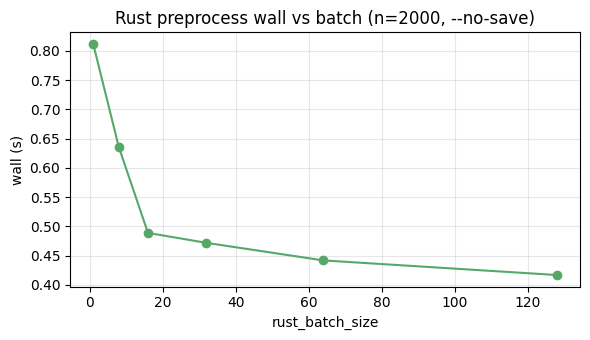

In [15]:
batch_sizes = [1, 8, 16, 32, 64, 128] if not SMOKE else [1, 16, 64, 128]
batch_rows: list[dict] = []

if RUN_RUST_BATCH_SWEEP:
    for bs in batch_sizes:
        wall, rc = bench_rust(rust_batch=bs, rayon_threads=None)
        batch_rows.append({"rust_batch_size": bs, "wall_s": wall, "rc": rc})
        print(f"rust_batch_size={bs:>4}  wall_s={wall}  rc={rc}")
    df_bs = pd.DataFrame(batch_rows)
    try:
        display(df_bs)
    except NameError:
        print(df_bs.to_string(index=False))

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(df_bs["rust_batch_size"], df_bs["wall_s"], "o-", color="#55A868")
    ax.set_xlabel("rust_batch_size")
    ax.set_ylabel("wall (s)")
    ax.set_title(f"Rust preprocess wall vs batch (n={PRE_LIMIT}, --no-save)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("SKIP: RUN_RUST_BATCH_SWEEP = False")

## 4. 학습 측 병렬 (`num_workers`)

`train/train.py` 는 위치 인자로 **`num_workers`** 를 받습니다. `train/train.sh` 에는 Windows·RDKit 이슈를 피하려 **`num_workers=0`** 기본 주석이 있으나, QDF 스택에서는 **4 전후**로 올려 IO·CPU 전처리를 겹치는 경우가 많습니다. **shard + `MyDatasetShard`** 사용 시 Windows에서는 예전처럼 worker pickle 문제가 나지 않도록 `dataset_shard` 쪽이 정리되어 있다는 전제(연구노트)에서 시도하세요.

전처리와 달리 **GPU/XPU가 지배적**이면 `num_workers` 이득은 상한이 낮습니다.

## 5. “더 빠르게” 우선순위 (실무)

1. **전처리 한 번만** 돌리고 **`--output-format shard`** 로 IO·파일 수를 줄인다.  
2. Rust 경로에서 **`--rust-batch-size`** 를 스윕해 최소 wall 을 고른다(본 노트 §3).  
3. **`RAYON_NUM_THREADS`** 를 물리 코어 수 근처로 맞춘다(§2).  
4. 학습에서 **`num_workers`** 를 0→2→4 로 올려 본다(메모리·Windows 안정성 확인).  
5. NumPy 전처리를 계속 쓸 경우에만 **OpenBLAS/MKL 스레드** 환경변수 튜닝을 검토(다른 작업과 CPU 경합 주의).  
6. **멀티프로세스로 분자 파일을 샤드 나눠 전처리**하는 것은 스크립트 미구현 상태 — 레포에 들어가면 운영 복잡도만큼 이득이 큰 편.

---

원본 벤치 요약: `rust_speed_efficiency_report.ipynb`

## 6. Python (NumPy) 백엔드 — BLAS 스레드 스윕

Rust 쪽 `RAYON_NUM_THREADS`에 대응하는 Python 쪽 노브는 **BLAS 스레드 수**입니다.  
NumPy가 내부적으로 쓰는 OpenBLAS/MKL/BLIS에 전달되는 환경변수 4가지를 동시에 설정합니다.

| 환경변수 | 대상 |
|----------|------|
| `OMP_NUM_THREADS` | OpenMP 기반 루틴 전체 |
| `OPENBLAS_NUM_THREADS` | OpenBLAS (conda 기본 NumPy) |
| `MKL_NUM_THREADS` | Intel MKL (pip NumPy ≥ 1.24) |
| `NUMEXPR_NUM_THREADS` | NumExpr (pandas 가속) |

> **참고:** NumPy 전처리는 분자 루프 자체가 Python 순차이므로, BLAS 스레드를 올려도 행렬 연산 내부만 빨라집니다.  
> 큰 이득을 원하면 §7처럼 **multiprocessing으로 분자를 나눠** 처리해야 합니다.

In [16]:
RUN_NUMPY_BLAS_SWEEP = True


def bench_numpy(*, blas_threads: str | None = None) -> tuple[float | None, int]:
    """NumPy 백엔드로 profile_preprocess.py 실행. blas_threads=None 이면 OS 기본값."""
    blas_env_keys = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    extra: dict[str, str] = {}
    if blas_threads is not None:
        for k in blas_env_keys:
            extra[k] = blas_threads
    cp = run_cmd(
        [
            str(PROFILE_PRE),
            "--dataset",
            "QM9under14atoms_atomizationenergy_eV",
            "--split",
            "train",
            "--limit",
            str(PRE_LIMIT),
            "--no-save",
            "--backend",
            "numpy",
        ],
        extra_env=extra,
    )
    return parse_wall(cp.stdout or ""), cp.returncode


numpy_rows: list[dict] = []
if RUN_NUMPY_BLAS_SWEEP:
    logical = os.cpu_count() or 8
    candidates = sorted({1, 2, 4, max(1, logical // 2), logical})
    for t in candidates:
        wall, rc = bench_numpy(blas_threads=str(t))
        numpy_rows.append({"BLAS_NUM_THREADS": t, "wall_s": wall, "rc": rc})
        print(f"BLAS_NUM_THREADS={t:>3}  wall_s={wall}  rc={rc}")
    df_numpy = pd.DataFrame(numpy_rows)
    try:
        display(df_numpy)
    except NameError:
        print(df_numpy.to_string(index=False))
else:
    print("SKIP: RUN_NUMPY_BLAS_SWEEP = False")

BLAS_NUM_THREADS=  1  wall_s=8.954  rc=0
BLAS_NUM_THREADS=  2  wall_s=8.513  rc=0
BLAS_NUM_THREADS=  4  wall_s=8.483  rc=0
BLAS_NUM_THREADS=  8  wall_s=8.709  rc=0


,BLAS_NUM_THREADS,wall_s,rc
0,1,8.954,0
1,2,8.513,0
2,4,8.483,0
3,8,8.709,0


## 7. Rust vs NumPy — 스레드 스케일링 통합 시각화

| 패널 | 내용 |
|------|------|
| **좌상** | 스레드 수별 절대 wall time (두 백엔드 겹쳐서) |
| **우상** | 스레드 1 기준 상대 속도향상(speedup) |
| **하** | 최적 설정 best-of 바 차트 + 배속 표시 |

C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\796690475.py:114: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.savefig(REPO / "examples" / "sslgraph" / "bench" / "figs" / "parallel_scaling_rust_vs_numpy.png",
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\796690475.py:114: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(REPO / "examples" / "sslgraph" / "bench" / "figs" / "parallel_scaling_rust_vs_numpy.png",
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\796690475.py:114: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.savefig(REPO / "examples" / "sslgraph" / "bench" / "figs" / "parallel_scaling_rust_vs_numpy.png",
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\796690475.py:114: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(REPO / "examples" / "sslgraph" / "bench" / "figs" / "paral

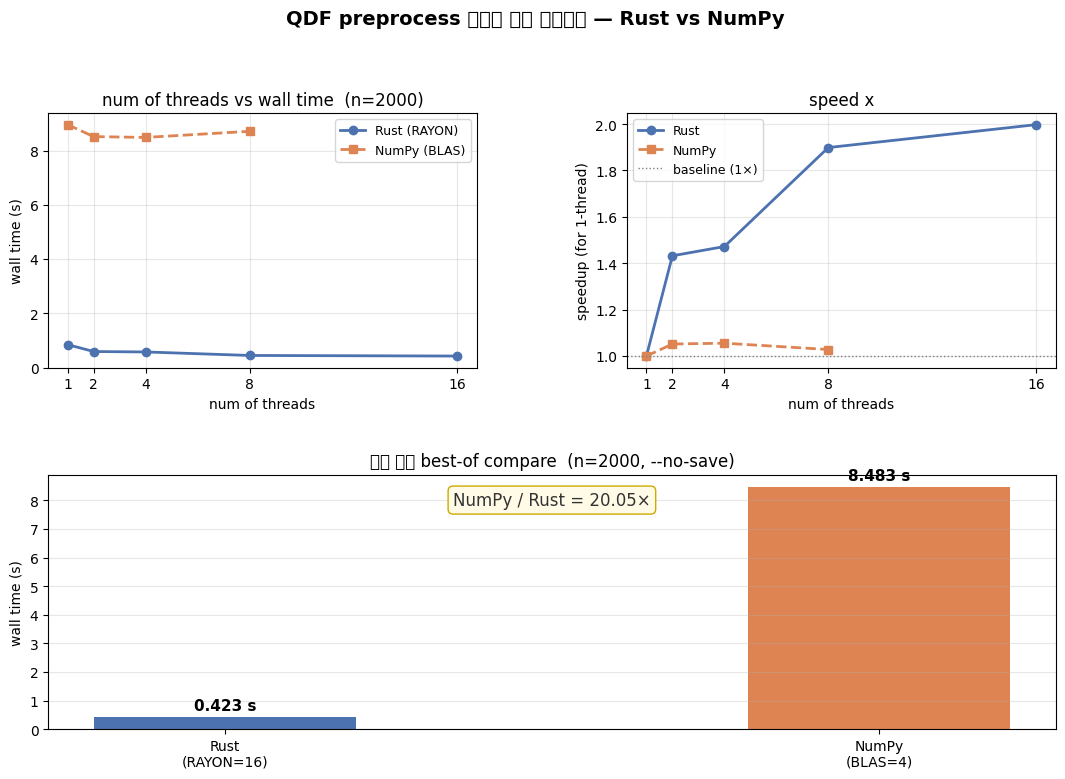


────────────────────────────────────────────────────
  Rust  best : RAYON= 16  →  0.423 s
  NumPy best : BLAS =  4  →  8.483 s
  NumPy / Rust = 20.05×  (Rust is fster then > 1)
────────────────────────────────────────────────────


In [17]:
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── 데이터 준비 ──────────────────────────────────────────────
def _extract(rows: list[dict], thread_key: str):
    """(threads, wall_s) list. wall_s=None excluded."""
    return [(r[thread_key], r["wall_s"]) for r in rows if r.get("wall_s") is not None]

rust_pts  = _extract(rayon_rows, "RAYON_NUM_THREADS") if "rayon_rows" in dir() else []
numpy_pts = _extract(numpy_rows, "BLAS_NUM_THREADS")  if "numpy_rows" in dir() else []

def _best(pts):
    return min(pts, key=lambda x: x[1]) if pts else (None, float("nan"))

rust_best_t,  rust_best_w  = _best(rust_pts)
numpy_best_t, numpy_best_w = _best(numpy_pts)

# ── 레이아웃 ─────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
ax_line  = fig.add_subplot(gs[0, 0])   # 좌상: 절대 wall
ax_speedup = fig.add_subplot(gs[0, 1]) # 우상: speedup
ax_bar   = fig.add_subplot(gs[1, :])   # 하:   best-of 바

C_RUST  = "#4C72B0"
C_NUMPY = "#DD8452"

# ── 좌상: 절대 wall time 꺾은선 ──────────────────────────────
if rust_pts:
    tx, ty = zip(*sorted(rust_pts))
    ax_line.plot(tx, ty, "o-", color=C_RUST,  label="Rust (RAYON)", lw=2, ms=6)
if numpy_pts:
    tx, ty = zip(*sorted(numpy_pts))
    ax_line.plot(tx, ty, "s--", color=C_NUMPY, label="NumPy (BLAS)", lw=2, ms=6)

ax_line.set_xlabel("num of threads")
ax_line.set_ylabel("wall time (s)")
ax_line.set_title(f"num of threads vs wall time  (n={PRE_LIMIT})")
ax_line.legend(fontsize=9)
ax_line.grid(True, alpha=0.3)
if rust_pts or numpy_pts:
    all_t = sorted({p[0] for p in rust_pts + numpy_pts})
    ax_line.set_xticks(all_t)

# ── 우상: 1-thread 대비 speedup ──────────────────────────────
def _speedup(pts):
    d = dict(pts)
    base = d.get(1)
    if base is None or base == 0:
        return []
    return sorted([(t, base / w) for t, w in d.items()])

rust_sp  = _speedup(rust_pts)
numpy_sp = _speedup(numpy_pts)

if rust_sp:
    tx, ty = zip(*rust_sp)
    ax_speedup.plot(tx, ty, "o-",  color=C_RUST,  label="Rust",  lw=2, ms=6)
if numpy_sp:
    tx, ty = zip(*numpy_sp)
    ax_speedup.plot(tx, ty, "s--", color=C_NUMPY, label="NumPy", lw=2, ms=6)

ax_speedup.axhline(1.0, color="gray", lw=1, ls=":", label="baseline (1×)")
ax_speedup.set_xlabel("num of threads")
ax_speedup.set_ylabel("speedup (for 1-thread)")
ax_speedup.set_title("speed x")
ax_speedup.legend(fontsize=9)
ax_speedup.grid(True, alpha=0.3)
if rust_sp or numpy_sp:
    all_t2 = sorted({p[0] for p in rust_sp + numpy_sp})
    ax_speedup.set_xticks(all_t2)

# ── 하: best-of 바 차트 ──────────────────────────────────────
bar_labels = []
bar_vals   = []
bar_colors = []

if not math.isnan(rust_best_w):
    bar_labels.append(f"Rust\n(RAYON={rust_best_t})")
    bar_vals.append(rust_best_w)
    bar_colors.append(C_RUST)
if not math.isnan(numpy_best_w):
    bar_labels.append(f"NumPy\n(BLAS={numpy_best_t})")
    bar_vals.append(numpy_best_w)
    bar_colors.append(C_NUMPY)

if bar_vals:
    bars = ax_bar.bar(bar_labels, bar_vals, color=bar_colors, width=0.4)
    ymax = max(bar_vals)
    for bar, v in zip(bars, bar_vals):
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2,
            v + ymax * 0.015,
            f"{v:.3f} s",
            ha="center", va="bottom", fontsize=11, fontweight="bold",
        )
    # speedup 주석 (두 값이 모두 있을 때)
    if len(bar_vals) == 2 and bar_vals[0] > 0 and bar_vals[1] > 0:
        ratio = bar_vals[1] / bar_vals[0]
        ax_bar.annotate(
            f"NumPy / Rust = {ratio:.2f}×",
            xy=(0.5, 0.88), xycoords="axes fraction",
            ha="center", fontsize=12, color="#333333",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", ec="#CCAA00", lw=1),
        )

ax_bar.set_ylabel("wall time (s)")
ax_bar.set_title(f"최적 설정 best-of compare  (n={PRE_LIMIT}, --no-save)")
ax_bar.grid(True, axis="y", alpha=0.3)

fig.suptitle("QDF preprocess 전처리 병렬 스케일링 — Rust vs NumPy", fontsize=14, fontweight="bold", y=1.01)
plt.savefig(REPO / "examples" / "sslgraph" / "bench" / "figs" / "parallel_scaling_rust_vs_numpy.png",
            dpi=150, bbox_inches="tight")
plt.show()

# 텍스트 요약
print(f"\n{'─'*52}")
if not math.isnan(rust_best_w):
    print(f"  Rust  best : RAYON={rust_best_t:>3}  →  {rust_best_w:.3f} s")
if not math.isnan(numpy_best_w):
    print(f"  NumPy best : BLAS ={numpy_best_t:>3}  →  {numpy_best_w:.3f} s")
if not math.isnan(rust_best_w) and not math.isnan(numpy_best_w) and rust_best_w > 0:
    print(f"  NumPy / Rust = {numpy_best_w / rust_best_w:.2f}×  (Rust is fster then > 1)")
print(f"{'─'*52}")

## 8. 그래프 개별 출력 — ① 절대 wall time / ② speedup / ③ best-of 바

C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1632002747.py:28: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing

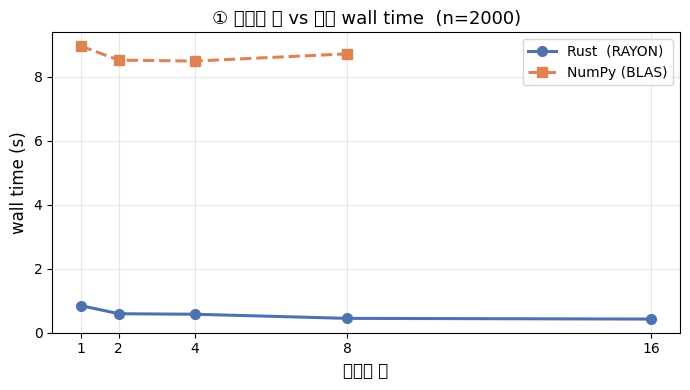

saved → figs/scale_wall.png


In [18]:
import math, matplotlib.pyplot as plt

FIGS_DIR = REPO / "examples" / "sslgraph" / "bench" / "figs"

def _pts(rows, key):
    return sorted([(r[key], r["wall_s"]) for r in rows if r.get("wall_s") is not None])

rust_pts_  = _pts(rayon_rows, "RAYON_NUM_THREADS") if "rayon_rows" in dir() and rayon_rows else []
numpy_pts_ = _pts(numpy_rows, "BLAS_NUM_THREADS")  if "numpy_rows" in dir() and numpy_rows else []

C_RUST, C_NUMPY = "#4C72B0", "#DD8452"

# ── ① 절대 wall time ─────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4))
if rust_pts_:
    tx, ty = zip(*rust_pts_)
    ax1.plot(tx, ty, "o-",  color=C_RUST,  lw=2.2, ms=7, label="Rust  (RAYON)")
if numpy_pts_:
    tx, ty = zip(*numpy_pts_)
    ax1.plot(tx, ty, "s--", color=C_NUMPY, lw=2.2, ms=7, label="NumPy (BLAS)")
ax1.set_xlabel("스레드 수", fontsize=12)
ax1.set_ylabel("wall time (s)", fontsize=12)
ax1.set_title(f"① 스레드 수 vs 절대 wall time  (n={PRE_LIMIT})", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
if rust_pts_ or numpy_pts_:
    ax1.set_xticks(sorted({p[0] for p in rust_pts_ + numpy_pts_}))
fig1.tight_layout()
fig1.savefig(FIGS_DIR / "scale_wall.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved → figs/scale_wall.png")

C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\238856679.py:34: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from 

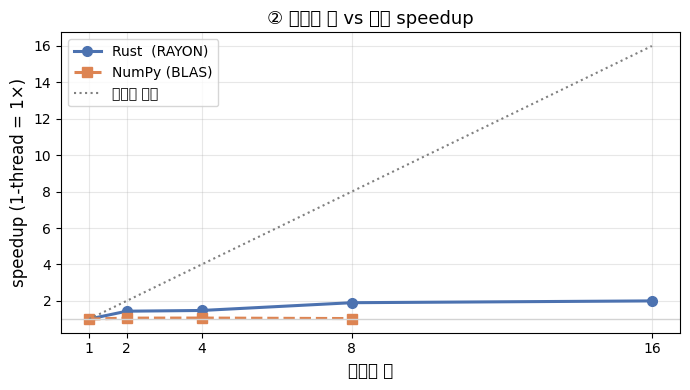

saved → figs/scale_speedup.png


In [19]:
# ── ② speedup (1-thread 기준) ───────────────────────────────
def _speedup(pts):
    d = dict(pts)
    base = d.get(1)
    if not base:
        return []
    return sorted([(t, base / w) for t, w in d.items()])

rust_sp_  = _speedup(rust_pts_)
numpy_sp_ = _speedup(numpy_pts_)

fig2, ax2 = plt.subplots(figsize=(7, 4))
if rust_sp_:
    tx, ty = zip(*rust_sp_)
    ax2.plot(tx, ty, "o-",  color=C_RUST,  lw=2.2, ms=7, label="Rust  (RAYON)")
if numpy_sp_:
    tx, ty = zip(*numpy_sp_)
    ax2.plot(tx, ty, "s--", color=C_NUMPY, lw=2.2, ms=7, label="NumPy (BLAS)")

# 이상적 선형 스케일링 (Rust 기준 범위)
if rust_pts_:
    all_t = [p[0] for p in rust_pts_]
    ideal = [t / all_t[0] for t in all_t]
    ax2.plot(all_t, ideal, ":", color="gray", lw=1.5, label="이상적 선형")

ax2.axhline(1.0, color="lightgray", lw=1)
ax2.set_xlabel("스레드 수", fontsize=12)
ax2.set_ylabel("speedup (1-thread = 1×)", fontsize=12)
ax2.set_title("② 스레드 수 vs 상대 speedup", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
if rust_sp_ or numpy_sp_:
    ax2.set_xticks(sorted({p[0] for p in rust_sp_ + numpy_sp_}))
fig2.tight_layout()
fig2.savefig(FIGS_DIR / "scale_speedup.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved → figs/scale_speedup.png")

C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\503307380.py:28: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing f

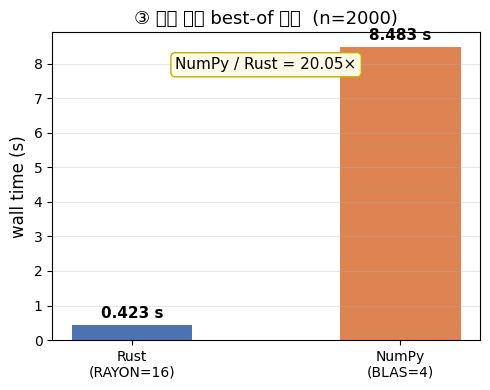

saved → figs/scale_bestof.png


In [20]:
# ── ③ best-of 바 차트 ────────────────────────────────────────
def _best(pts):
    return min(pts, key=lambda x: x[1]) if pts else (None, float("nan"))

rust_bt,  rust_bw  = _best(rust_pts_)
numpy_bt, numpy_bw = _best(numpy_pts_)

bar_labels, bar_vals, bar_colors = [], [], []
if not math.isnan(rust_bw):
    bar_labels.append(f"Rust\n(RAYON={rust_bt})"); bar_vals.append(rust_bw); bar_colors.append(C_RUST)
if not math.isnan(numpy_bw):
    bar_labels.append(f"NumPy\n(BLAS={numpy_bt})"); bar_vals.append(numpy_bw); bar_colors.append(C_NUMPY)

fig3, ax3 = plt.subplots(figsize=(5, 4))
if bar_vals:
    bars = ax3.bar(bar_labels, bar_vals, color=bar_colors, width=0.45)
    ymax = max(bar_vals)
    for bar, v in zip(bars, bar_vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, v + ymax * 0.015,
                 f"{v:.3f} s", ha="center", va="bottom", fontsize=11, fontweight="bold")
    if len(bar_vals) == 2 and bar_vals[0] > 0:
        ax3.annotate(f"NumPy / Rust = {bar_vals[1]/bar_vals[0]:.2f}×",
                     xy=(0.5, 0.88), xycoords="axes fraction", ha="center", fontsize=11,
                     bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", ec="#CCAA00", lw=1))
ax3.set_ylabel("wall time (s)", fontsize=12)
ax3.set_title(f"③ 최적 설정 best-of 비교  (n={PRE_LIMIT})", fontsize=13)
ax3.grid(True, axis="y", alpha=0.3)
fig3.tight_layout()
fig3.savefig(FIGS_DIR / "scale_bestof.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved → figs/scale_bestof.png")

## 9. 진행에 따른 자원 사용량 (CPU% · RSS · 스레드 수)

`psutil`로 서브프로세스를 **0.05 s 간격** 샘플링하며 `bench_with_usage()` 를 실행합니다.  
Rust vs NumPy 각각 **최적 스레드 수**로 한 번씩 돌리고 시계열을 겹쳐 표시합니다.

> 주의: 이 셀은 `profile_preprocess.py` 를 2회 실행하므로 약간의 시간이 걸립니다.

In [21]:
import threading, time, subprocess, os
import psutil
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SAMPLE_INTERVAL = 0.05  # seconds


def bench_with_usage(
    *,
    backend: str,
    thread_count: int,
    rust_batch: int = 64,
) -> dict:
    """
    profile_preprocess.py 를 실행하면서 psutil 로 CPU%·RSS·스레드 수를 샘플링.
    Returns dict with keys: wall_s, times, cpu_pcts, rss_mb, n_threads, stdout, rc
    """
    blas_keys = ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]
    env = os.environ.copy()
    if backend == "rust":
        env["RAYON_NUM_THREADS"] = str(thread_count)
    else:
        for k in blas_keys:
            env[k] = str(thread_count)

    argv = [
        str(PYTHON), str(PROFILE_PRE),
        "--dataset", "QM9under14atoms_atomizationenergy_eV",
        "--split", "train",
        "--limit", str(PRE_LIMIT),
        "--no-save",
        "--backend", backend,
    ]
    if backend == "rust":
        argv += ["--rust-batch-size", str(rust_batch)]

    times, cpu_pcts, rss_mb, n_threads = [], [], [], []
    stop_flag = threading.Event()

    proc = subprocess.Popen(argv, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    def _sampler():
        try:
            ps = psutil.Process(proc.pid)
            ps.cpu_percent()          # 첫 호출은 버림 (초기화)
            t0 = time.perf_counter()
            while not stop_flag.is_set():
                try:
                    mi = ps.memory_info()
                    times.append(time.perf_counter() - t0)
                    cpu_pcts.append(ps.cpu_percent())
                    rss_mb.append(mi.rss / 1024 / 1024)
                    n_threads.append(ps.num_threads())
                except (psutil.NoSuchProcess, psutil.AccessDenied):
                    break
                time.sleep(SAMPLE_INTERVAL)
        except Exception:
            pass

    t_start = time.perf_counter()
    sampler = threading.Thread(target=_sampler, daemon=True)
    sampler.start()

    stdout, _ = proc.communicate()
    stop_flag.set()
    sampler.join(timeout=2)
    wall = time.perf_counter() - t_start

    return dict(wall_s=wall, times=times, cpu_pcts=cpu_pcts,
                rss_mb=rss_mb, n_threads=n_threads, stdout=stdout, rc=proc.returncode)


# 최적 스레드 수 결정 (앞 스윕 결과 재활용, 없으면 os.cpu_count())
def _opt_threads(pts):
    if pts:
        return min(pts, key=lambda x: x[1])[0]
    return os.cpu_count() or 4

rust_opt  = _opt_threads(rust_pts_)
numpy_opt = _opt_threads(numpy_pts_)

print(f"Rust  최적 RAYON_NUM_THREADS = {rust_opt}")
print(f"NumPy 최적 BLAS_NUM_THREADS  = {numpy_opt}")
print("샘플링 실행 중 …")

r_rust  = bench_with_usage(backend="rust",  thread_count=rust_opt)
r_numpy = bench_with_usage(backend="numpy", thread_count=numpy_opt)

print(f"  Rust  wall={r_rust['wall_s']:.3f}s  rc={r_rust['rc']}")
print(f"  NumPy wall={r_numpy['wall_s']:.3f}s  rc={r_numpy['rc']}")

Rust  최적 RAYON_NUM_THREADS = 16
NumPy 최적 BLAS_NUM_THREADS  = 4
샘플링 실행 중 …
  Rust  wall=0.859s  rc=0
  NumPy wall=9.365s  rc=0


C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\aiden\AppData\Local\Temp\ipykernel_37112\1169431451.py:41: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from 

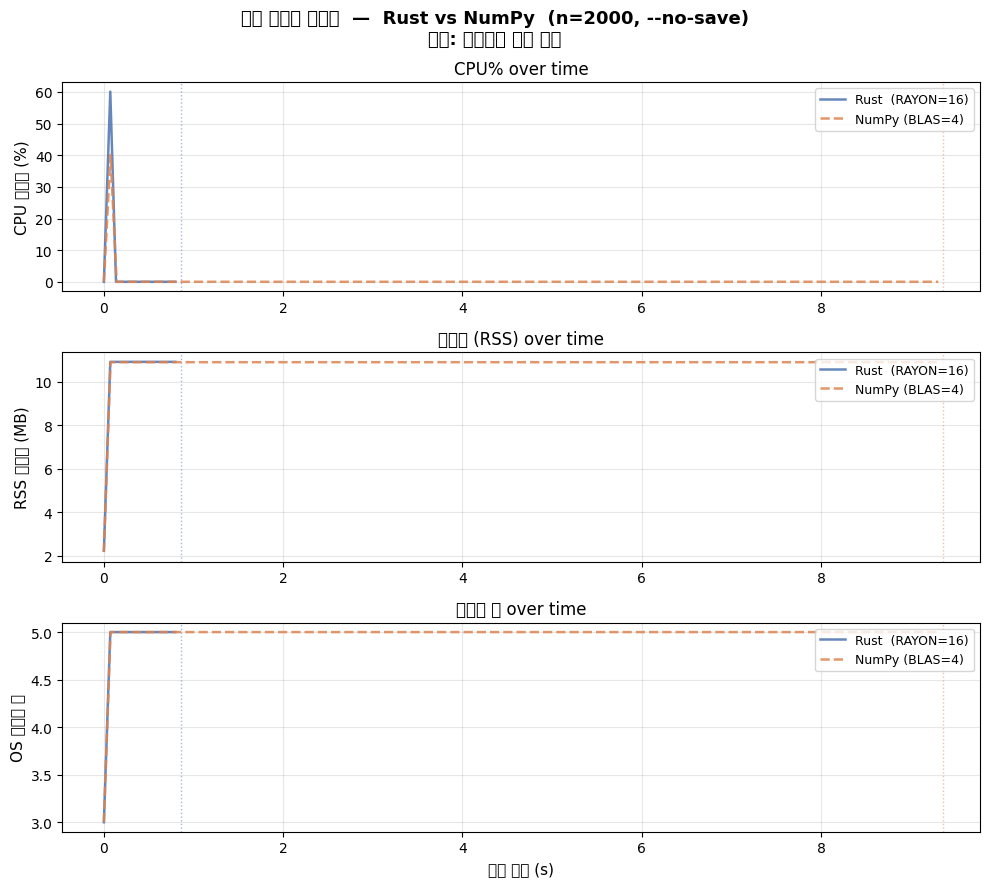

saved → figs/usage_timeseries.png


In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)
ax_cpu, ax_rss, ax_thr = axes

for r, label, color, ls in [
    (r_rust,  f"Rust  (RAYON={rust_opt})",  C_RUST,  "-"),
    (r_numpy, f"NumPy (BLAS={numpy_opt})",  C_NUMPY, "--"),
]:
    if not r["times"]:
        continue
    t = r["times"]

    # ─ CPU% ─
    ax_cpu.plot(t, r["cpu_pcts"], ls, color=color, lw=1.8, label=label, alpha=0.85)
    ax_cpu.axvline(r["wall_s"], color=color, lw=1, ls=":", alpha=0.5)

    # ─ RSS ─
    ax_rss.plot(t, r["rss_mb"], ls, color=color, lw=1.8, label=label, alpha=0.85)
    ax_rss.axvline(r["wall_s"], color=color, lw=1, ls=":", alpha=0.5)

    # ─ 스레드 수 ─
    ax_thr.plot(t, r["n_threads"], ls, color=color, lw=1.8, label=label, alpha=0.85)
    ax_thr.axvline(r["wall_s"], color=color, lw=1, ls=":", alpha=0.5)

for ax, ylabel, title in [
    (ax_cpu, "CPU 사용률 (%)",    "CPU% over time"),
    (ax_rss, "RSS 메모리 (MB)",   "메모리 (RSS) over time"),
    (ax_thr, "OS 스레드 수",      "스레드 수 over time"),
]:
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

ax_thr.set_xlabel("경과 시간 (s)", fontsize=11)

fig.suptitle(
    f"자원 사용량 시계열  —  Rust vs NumPy  (n={PRE_LIMIT}, --no-save)\n"
    f"점선: 프로세스 종료 시점",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGS_DIR / "usage_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved → figs/usage_timeseries.png")